In [1]:
import scanpy as sc 
import pandas as pd
import numpy as np
import os

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: 

In [43]:
## load neck integrated adata 
neck_inte_file = '/mnt/files/syy/adipose/neck/Analysis_new_markers_Nov272023/30sample_SCVI_integration_2023_12_15/adata_integrated_soupXoutput_with_infer.h5ad'
neck_adata = sc.read_h5ad(neck_inte_file)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [3]:
neck_adata


AnnData object with n_obs × n_vars = 41337 × 32981
    obs: 'sample', '_scvi_batch', '_scvi_labels', 'leiden_scVI', '_scvi_raw_norm_scaling'
    var: 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts', 'log_10k_norm'
    obsp: 'connectivities', 'distances'

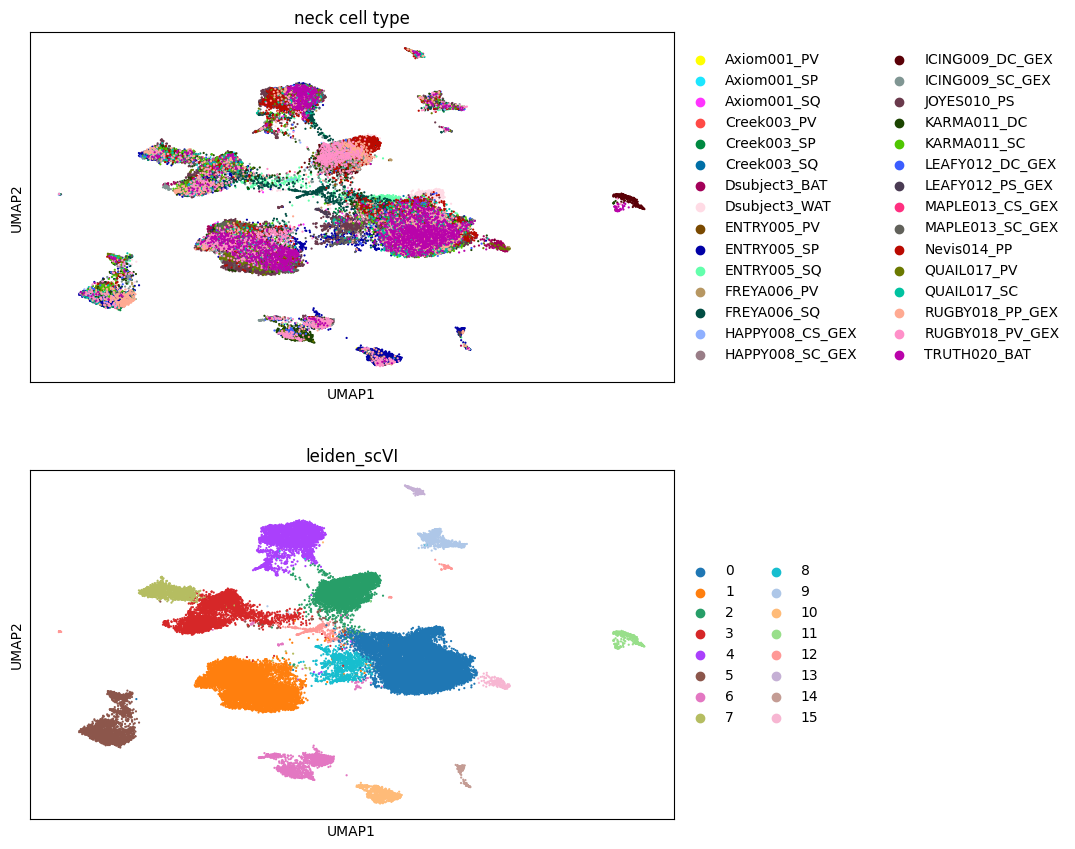

In [7]:
sc.pl.umap(neck_adata, color=['sample', 'leiden_scVI'],  title='neck cell type', size=10, wspace=0.4, ncols=1)

In [8]:
## load cell-type annotation by Henqrique/Sean 
rna_celltype_annotation_file = '/home/syyang/GitRepo/atac/Analysis_adipose/Henrique_Sean_RNAonly_celltype_multiome_samples.csv'
rna_celltype_annotation = pd.read_csv(rna_celltype_annotation_file, sep=',', index_col=0)
rna_celltype_annotation['Sample'] = rna_celltype_annotation['sample'].apply(lambda x: x.upper()) # make it sample name upper case
rna_celltype_annotation['rna_barcodes'] = rna_celltype_annotation['barcode'].apply(lambda x: x.split('-')[0])

In [48]:
rna_celltype_annotation.head()

,cell_type,sample,barcode,Sample,rna_barcodes
bc,,,,,
ACGTACAAGACCTTTG-1_AXIOM001_PV,Arterial Endothelial Cells,Axiom001_PV,ACGTACAAGACCTTTG-1_Axiom001_PV,AXIOM001_PV,ACGTACAAGACCTTTG
ACGGTTAAGTGTGTTC-1_AXIOM001_PV,Smooth Muscle Cells,Axiom001_PV,ACGGTTAAGTGTGTTC-1_Axiom001_PV,AXIOM001_PV,ACGGTTAAGTGTGTTC
CGGGACTAGGTTACCT-1_AXIOM001_PV,Lymphatic Endothelial Cells,Axiom001_PV,CGGGACTAGGTTACCT-1_Axiom001_PV,AXIOM001_PV,CGGGACTAGGTTACCT
TGCTTCGCAAGCACAG-1_AXIOM001_PV,White Adipocytes,Axiom001_PV,TGCTTCGCAAGCACAG-1_Axiom001_PV,AXIOM001_PV,TGCTTCGCAAGCACAG
ACGTAACCAATAGAGT-1_AXIOM001_PV,Smooth Muscle Cells,Axiom001_PV,ACGTAACCAATAGAGT-1_Axiom001_PV,AXIOM001_PV,ACGTAACCAATAGAGT


In [ ]:
# preparing for join cell type annotation with neck_adata
# match sample names 
neck_adata.obs['Sample'] = neck_adata.obs['sample'].apply(lambda x: x.upper().split('_GEX')[0]) # make it sample name upper case
neck_adata.obs['bc'] = neck_adata.obs.reset_index(inplace=False, drop=False).apply(lambda x: x['index'] + '_' + x['Sample'], axis=1).values
neck_adata.obs.reset_index(inplace=True, drop=False)
neck_adata.obs.set_index('bc', inplace=True, drop=True)
print(neck_adata.obs.head())


rna_celltype_annotation['bc'] = rna_celltype_annotation['rna_barcodes'] + '-1_' + rna_celltype_annotation['Sample']
rna_celltype_annotation.set_index('bc', inplace=True, drop=True)

print(rna_celltype_annotation.head()
      )



,index,sample,_scvi_batch,_scvi_labels,leiden_scVI,_scvi_raw_norm_scaling,Sample
bc,,,,,,,
ACGTACAAGACCTTTG-1_AXIOM001_PV,ACGTACAAGACCTTTG-1,Axiom001_PV,0,0,7,2.441662,AXIOM001_PV
ACGGTTAAGTGTGTTC-1_AXIOM001_PV,ACGGTTAAGTGTGTTC-1,Axiom001_PV,0,0,5,3.028156,AXIOM001_PV
CGGGACTAGGTTACCT-1_AXIOM001_PV,CGGGACTAGGTTACCT-1,Axiom001_PV,0,0,6,3.296581,AXIOM001_PV
TGCTTCGCAAGCACAG-1_AXIOM001_PV,TGCTTCGCAAGCACAG-1,Axiom001_PV,0,0,0,3.308049,AXIOM001_PV
ACGTAACCAATAGAGT-1_AXIOM001_PV,ACGTAACCAATAGAGT-1,Axiom001_PV,0,0,5,3.377956,AXIOM001_PV


In [52]:
neck_adata.obs = neck_adata.obs.join(rna_celltype_annotation[['cell_type', 'rna_barcodes']], how='left', on='bc')

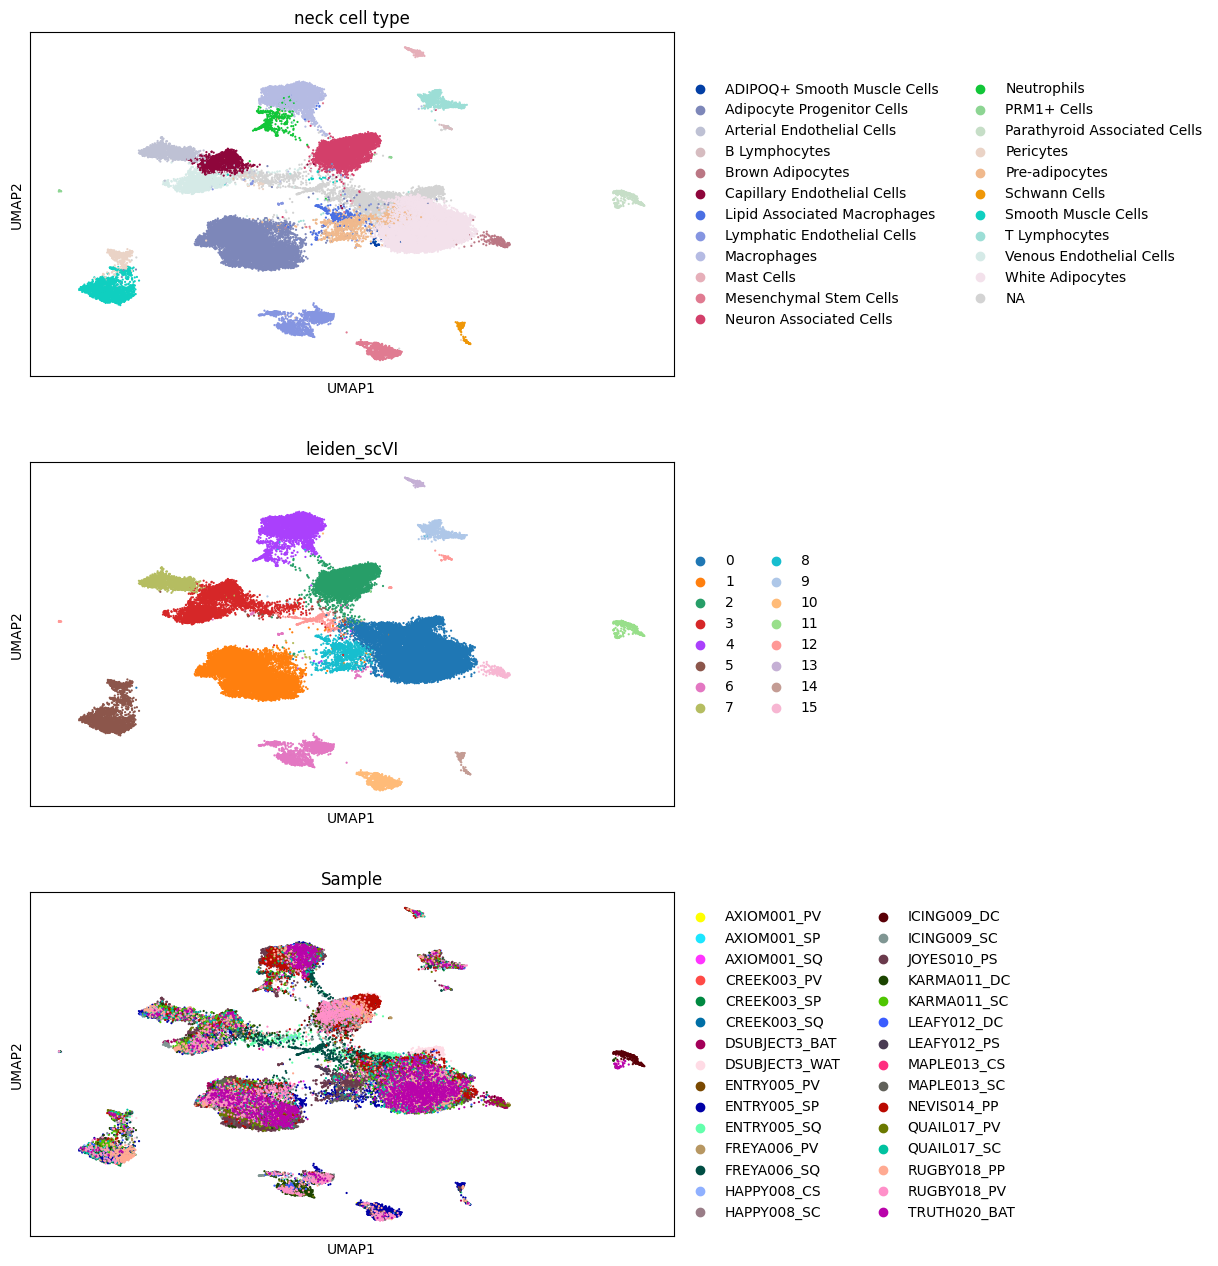

In [54]:
# plot 
sc.pl.umap(neck_adata, color=['cell_type',  'leiden_scVI', 'Sample'] ,  title='neck cell type', size=10, wspace=0.4, ncols=1)

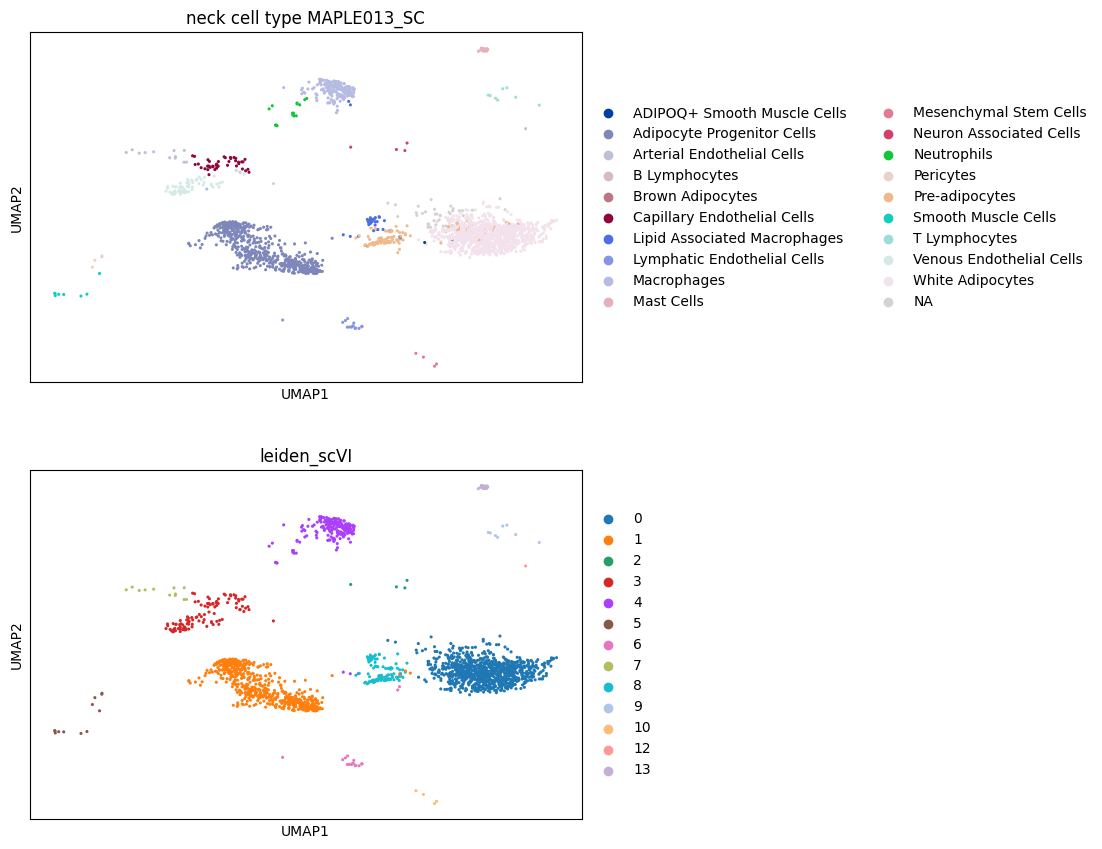

In [59]:
# plot only MAPLE013_SC
maple013_sc_adata = neck_adata[neck_adata.obs['Sample'] == 'MAPLE013_SC', :]
sc.pl.umap(maple013_sc_adata, color=['cell_type', 'leiden_scVI'], title='neck cell type MAPLE013_SC', size=20, wspace=0.2, ncols=1)